In [6]:
# Nettoyage complet
print("Nettoyage...")
%reset -f

%whos

Nettoyage...
Interactive namespace is empty.


In [7]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
import geopandas as gpd
from sklearn.neighbors import KernelDensity
import folium

In [8]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

requete_agence_transaction = """ 
SELECT agence_id FROM dbo.t_transaction
"""

agence_transaction = pd.read_sql_query(requete_agence_transaction, conn)

conn.commit()
cursor.close()
conn.close()

C:\Users\quent\AppData\Local\Temp\ipykernel_2060\1839446035.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  agence_transaction = pd.read_sql_query(requete_agence_transaction, conn)


<Axes: >

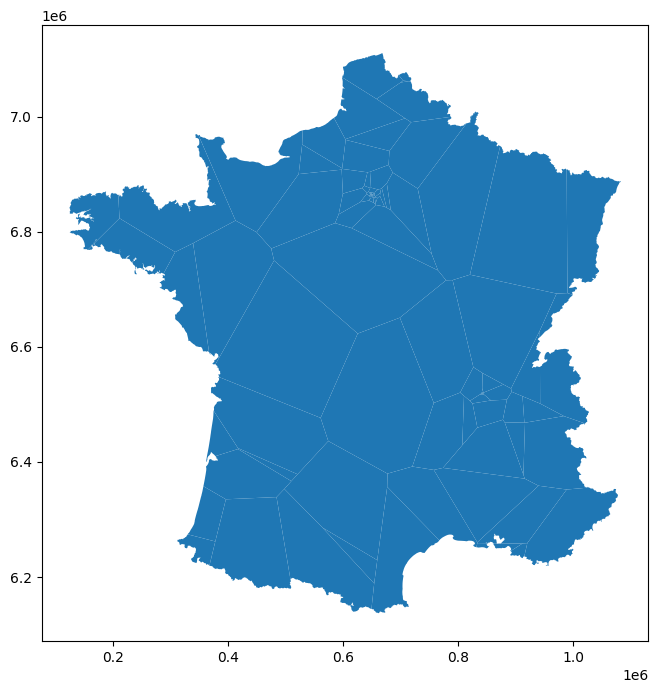

In [ ]:
gdf = gpd.read_file("gdf_agences_polygones.geojson")
gdf.head()
gdf.plot(figsize=(8,8))

In [10]:
count_df = agence_transaction.groupby("agence_id").size().reset_index(name="nb_transactions")

agence_transaction = (
    agence_transaction
    .drop_duplicates(subset=["agence_id"])
    .merge(count_df, on="agence_id", how="left")
)

agence_transaction.head()

,agence_id,nb_transactions
0,8.0,26.0
1,10.0,13.0
2,18.0,7310.0
3,24.0,1018.0
4,25.0,2923.0
